# 3. Baseline Model (TF-IDF + Linear Classifier)

**Goal**: Establish a strong, interpretable baseline to prove that the final transformer model genuinely adds value.
**Model**: Character-level TF-IDF (3-5 n-grams) + Linear SVM.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import os

# Set style
sns.set(style='whitegrid')
print("Libraries imported.")

Libraries imported.


## 3.1 Load Data

In [6]:
train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/val.xlsx')

print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")

X_train = train_df['cleaned_poem'].astype(str)
y_train = train_df['label_id']

X_val = val_df['cleaned_poem'].astype(str)
y_val = val_df['label_id']

# Load label map for reference
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/label_map.json', 'r') as f:
    label_map = json.load(f)
id_to_label = {v: k for k, v in label_map.items()}

Train samples: 3299
Val samples:   825


## 3.2 Feature Extraction (TF-IDF)
- Character n-grams: 3 to 5

In [7]:
vectorizer = TfidfVectorizer(
    analyzer='char', 
    ngram_range=(3, 5), 
    min_df=5,
    sublinear_tf=True
)

print("Vectorizing training data...")
X_train_tfidf = vectorizer.fit_transform(X_train)
print(f"Train Feature shape: {X_train_tfidf.shape}")

print("Vectorizing validation data...")
X_val_tfidf = vectorizer.transform(X_val)
print(f"Val Feature shape:   {X_val_tfidf.shape}")

Vectorizing training data...
Train Feature shape: (3299, 85597)
Vectorizing validation data...
Val Feature shape:   (825, 85597)


## 3.3 Model Training
- Linear SVM
- Class Weights: Balanced

In [8]:
model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
print("Training Linear SVM...")
model.fit(X_train_tfidf, y_train)
print("Training complete.")

Training Linear SVM...
Training complete.


## 3.5 Evaluation
- Accuracy
- Macro F1 (PRIMARY)
- Weighted F1

In [9]:
y_pred = model.predict(X_val_tfidf)

acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average='macro')
weighted_f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Accuracy:    {acc:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Accuracy:    0.4000
Macro F1:    0.2579
Weighted F1: 0.3961


In [10]:
# Save Metrics
metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1
}

reports_dir = 'round1/reports'
os.makedirs(reports_dir, exist_ok=True)
with open(f'{reports_dir}/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {reports_dir}/baseline_metrics.json")

Metrics saved to round1/reports/baseline_metrics.json


### Confusion Matrix & Error Analysis

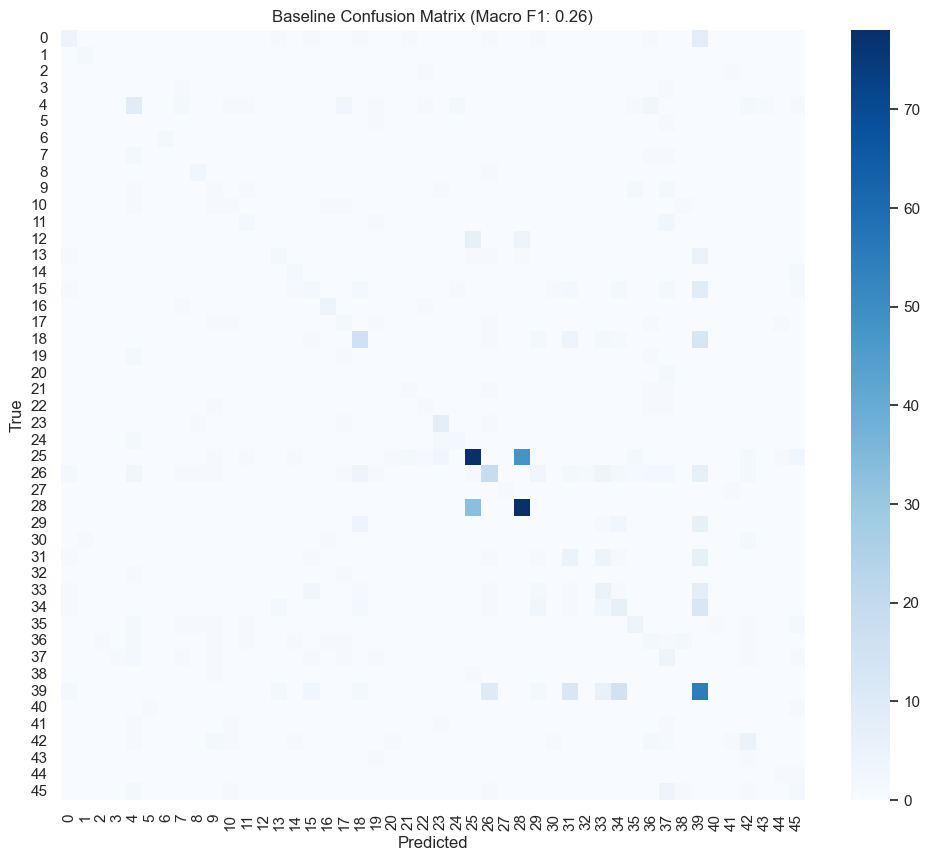

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', fmt='d')
plt.title(f'Baseline Confusion Matrix (Macro F1: {macro_f1:.2f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(f'{reports_dir}/baseline_confusion_matrix.png')
plt.show()

In [12]:
# Save Top Errors
results = pd.DataFrame({'True': y_val, 'Predicted': y_pred})
results['True_Label'] = results['True'].map(id_to_label)
results['Pred_Label'] = results['Predicted'].map(id_to_label)

errors = results[results['True'] != results['Predicted']]
errors.to_csv(f'{reports_dir}/baseline_errors.csv', index=False)
print(f"Errors saved to {reports_dir}/baseline_errors.csv")
print("Total Errors:", len(errors))

Errors saved to round1/reports/baseline_errors.csv
Total Errors: 495
